# Notebook 06 — Pipeline Score Rules
## Monte Carlo + Ranked Probability Score | Projeto Fórmula 1 — TCC

Este notebook apresenta e analisa os resultados do **Pipeline Score Rules**,
que incrementa o Pipeline 1 adicionando previsão probabilística via
Monte Carlo e avaliação via Ranked Probability Score (RPS).

### Estrutura do notebook
1. Configuração e carregamento dos resultados
2. Vetor de probabilidades — o que é e como interpretar
3. RPS — Ranked Probability Score
4. Visualizações
5. Análise de casos específicos
6. Conclusões


## 1. Configuração

In [11]:
import sys
import pickle
import numpy as np
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import defaultdict
from pathlib import Path

# ── Caminhos relativos à raiz do repositório ──────────────────────────────
# O notebook fica em notebooks/ → subir um nível chega à raiz do projeto
PROJECT_ROOT  = Path('.').resolve().parent
PIPELINE2_DIR = PROJECT_ROOT / 'src' / 'pipeline_score_rules'

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# ── Imports dos módulos do projeto ────────────────────────────────────────
from src.pipeline_score_rules.visualization_plots_p2 import (
    plot_probability_heatmap,
    plot_rps_evolution,
    plot_win_probabilities,
    plot_rps_gain,
)
from src.pipeline_score_rules.scoring_rules             import rps_season_summary
from src.pipeline_mallows_plackett_luce.visualization_plots import TEAM_COLORS

# ── Carregar dados gerados pelo run_pipeline_score_rules.py ───────────────
pkl_path = PIPELINE2_DIR / 'outputs' / 'nb_data_p2.pkl'

if not pkl_path.exists():
    raise FileNotFoundError(
        f"Arquivo não encontrado: {pkl_path}\n"
        "Execute primeiro:\n"
        "    python -m src.pipeline_score_rules.run_pipeline_score_rules"
    )

with open(pkl_path, 'rb') as f:
    data = pickle.load(f)

state              = data['state']
val_evals          = data['val_evals']
test_evals         = data['test_evals']
val_rps            = data['val_rps']
test_rps           = data['test_rps']
val_rps_summary    = data['val_rps_summary']
test_rps_summary   = data['test_rps_summary']
val_distributions  = data['val_distributions']
test_distributions = data['test_distributions']
val_records        = data['val_records']
test_records       = data['test_records']
all_drivers        = data['all_drivers']

print("Dados carregados com sucesso.")
print(f"  Projeto raiz   : {PROJECT_ROOT}")
print(f"  Arquivo pkl    : {pkl_path}")
print(f"  Val (2023)     : {len(val_rps)} corridas")
print(f"  Teste (2024)   : {len(test_rps)} corridas")


Dados carregados com sucesso.
  Projeto raiz   : C:\Users\guiga\OneDrive\Documentos\Projeto-Formula1
  Arquivo pkl    : C:\Users\guiga\OneDrive\Documentos\Projeto-Formula1\src\pipeline_score_rules\outputs\nb_data_p2.pkl
  Val (2023)     : 22 corridas
  Teste (2024)   : 24 corridas


## 2. Vetor de Probabilidades

### O que é e como é gerado

Para cada corrida, o Monte Carlo usa os skill scores λ_i do cluster
identificado pelo Mallows e simula **10.000 corridas** usando esses scores
como pesos. Cada piloto é "sorteado" para cada posição proporcional ao seu λ_i.

O resultado é um vetor por piloto:
```
VER → [P(1º), P(2º), P(3º), ..., P(10º)]
      [0.45,  0.22,  0.13,  ..., 0.01  ]
```

A soma de cada vetor é sempre 1.0. A soma de todos os P(1º) de todos os
pilotos também é 1.0 — alguém sempre vence.


In [12]:
# Exibir vetor de probabilidades da primeira corrida de 2024
dist  = test_distributions[0]
race  = test_records[0].race
print(f"Distribuição de probabilidades — {race} {test_records[0].season}")
print(f"\n  {'Piloto':>6}  {'P(1º)':>7}  {'P(2º)':>7}  {'P(3º)':>7}  "
      f"{'P(4º)':>7}  {'P(5º)':>7}  {'Top-3':>7}  {'Pos. Esp.':>10}")
print("  " + "-" * 70)

win_probs = dist.win_probabilities()
for driver in list(win_probs.keys())[:10]:
    vec = dist.vectors[driver]
    p   = vec.probs
    print(f"  {driver:>6}  {p[0]:>7.3f}  {p[1]:>7.3f}  {p[2]:>7.3f}  "
          f"{p[3]:>7.3f}  {p[4]:>7.3f}  {vec.p_top_n(3):>7.3f}  "
          f"{vec.expected_position():>10.2f}")


Distribuição de probabilidades — Bahrain 2024

  Piloto    P(1º)    P(2º)    P(3º)    P(4º)    P(5º)    Top-3   Pos. Esp.
  ----------------------------------------------------------------------
     VER    0.221    0.183    0.146    0.120    0.090    0.551        3.90
     PER    0.106    0.102    0.089    0.092    0.085    0.297        6.57
     HAM    0.096    0.096    0.094    0.087    0.083    0.286        6.74
     ALO    0.053    0.055    0.054    0.060    0.062    0.162        8.62
     KUB    0.040    0.042    0.048    0.046    0.051    0.130        9.12
     RUS    0.038    0.043    0.045    0.048    0.051    0.126        9.11
     SAI    0.037    0.038    0.042    0.041    0.047    0.117        9.25
     LAW    0.037    0.037    0.043    0.041    0.041    0.117        9.18
     GAS    0.032    0.032    0.036    0.037    0.039    0.100        9.23
     BOT    0.032    0.033    0.034    0.036    0.041    0.100        9.14


## 3. RPS — Ranked Probability Score

### O que mede

O RPS avalia a **qualidade das probabilidades** — não só se o modelo acertou
o vencedor, mas se a distribuição inteira era coerente com o resultado.

```
RPS = (1/K) × Σ (CDF_prevista(k) - CDF_real(k))²
```

- **RPS = 0.0** → previsão perfeita
- **RPS baseline** ≈ 0.13 (modelo que não sabe nada sobre F1)
- **Ganho** = RPS_baseline − RPS_modelo

Um ganho positivo significa que o modelo foi **mais informativo** que
atribuir probabilidade igual a todos os pilotos.


In [13]:
# Tabela RPS — validação 2023
print("RPS — VALIDAÇÃO 2023")
print(f"\n  {'Corrida':22s} {'Cluster':>8} {'RPS Modelo':>12} "
      f"{'RPS Baseline':>14} {'Ganho':>8}")
print("  " + "-" * 68)
for r in val_rps:
    marker = "✓" if r.gain > 0 else "✗"
    print(f"  {r.race:22s} {r.cluster+1:>8d} {r.rps_model:>12.4f} "
          f"{r.rps_baseline:>14.4f} {r.gain:>8.4f} {marker}")
print("  " + "-" * 68)
print(f"  {'MÉDIA':22s} {'':>8} {val_rps_summary.mean_rps_model:>12.4f} "
      f"{val_rps_summary.mean_rps_baseline:>14.4f} "
      f"{val_rps_summary.mean_gain:>8.4f}")


RPS — VALIDAÇÃO 2023

  Corrida                 Cluster   RPS Modelo   RPS Baseline    Ganho
  --------------------------------------------------------------------
  Bahrain                       2       0.1484         0.1903   0.0419 ✓
  Saudi Arabia                  1       0.1215         0.1903   0.0688 ✓
  Australia                     1       0.1680         0.1903   0.0222 ✓
  Azerbaijan                    1       0.1341         0.1903   0.0562 ✓
  Miami                         1       0.1180         0.1889   0.0709 ✓
  Monaco                        2       0.1629         0.1899   0.0270 ✓
  Spain                         1       0.1307         0.1889   0.0582 ✓
  Canada                        1       0.1342         0.1903   0.0561 ✓
  Austria                       1       0.1130         0.1899   0.0769 ✓
  Great Britain                 2       0.1543         0.1903   0.0359 ✓
  Hungary                       2       0.1525         0.1903   0.0378 ✓
  Belgium                       1

In [14]:
# Tabela RPS — teste 2024
print("RPS — TESTE 2024")
print(f"\n  {'Corrida':22s} {'Cluster':>8} {'RPS Modelo':>12} "
      f"{'RPS Baseline':>14} {'Ganho':>8}")
print("  " + "-" * 68)
for r in test_rps:
    marker = "✓" if r.gain > 0 else "✗"
    print(f"  {r.race:22s} {r.cluster+1:>8d} {r.rps_model:>12.4f} "
          f"{r.rps_baseline:>14.4f} {r.gain:>8.4f} {marker}")
print("  " + "-" * 68)
print(f"  {'MÉDIA':22s} {'':>8} {test_rps_summary.mean_rps_model:>12.4f} "
      f"{test_rps_summary.mean_rps_baseline:>14.4f} "
      f"{test_rps_summary.mean_gain:>8.4f}")


RPS — TESTE 2024

  Corrida                 Cluster   RPS Modelo   RPS Baseline    Ganho
  --------------------------------------------------------------------
  Bahrain                       2       0.1368         0.1889   0.0522 ✓
  Saudi Arabia                  2       0.1655         0.1903   0.0247 ✓
  Australia                     2       0.1921         0.1903  -0.0019 ✗
  Japan                         1       0.1219         0.1903   0.0684 ✓
  China                         2       0.1374         0.1903   0.0529 ✓
  Miami                         1       0.1346         0.1899   0.0553 ✓
  Emilia Romagna                2       0.1594         0.1899   0.0304 ✓
  Monaco                        1       0.1302         0.1899   0.0598 ✓
  Canada                        1       0.1280         0.1894   0.0614 ✓
  Spain                         1       0.1153         0.1889   0.0737 ✓
  Austria                       2       0.1564         0.1889   0.0326 ✓
  Great Britain                 2    

In [15]:
# Resumo comparativo
print("RESUMO COMPARATIVO")
print(f"\n  {'Split':20s} {'RPS Modelo':>12} {'RPS Baseline':>14} "
      f"{'Ganho Médio':>12} {'Corridas':>10}")
print("  " + "-" * 72)
print(f"  {'Validação 2023':20s} {val_rps_summary.mean_rps_model:>12.4f} "
      f"{val_rps_summary.mean_rps_baseline:>14.4f} "
      f"{val_rps_summary.mean_gain:>12.4f} {val_rps_summary.n_races:>10}")
print(f"  {'Teste 2024':20s} {test_rps_summary.mean_rps_model:>12.4f} "
      f"{test_rps_summary.mean_rps_baseline:>14.4f} "
      f"{test_rps_summary.mean_gain:>12.4f} {test_rps_summary.n_races:>10}")

pct_val  = val_rps_summary.mean_gain  / val_rps_summary.mean_rps_baseline  * 100
pct_test = test_rps_summary.mean_gain / test_rps_summary.mean_rps_baseline * 100
print(f"\n  Melhoria sobre baseline:")
print(f"    Validação 2023: {pct_val:.1f}%")
print(f"    Teste 2024:     {pct_test:.1f}%")


RESUMO COMPARATIVO

  Split                  RPS Modelo   RPS Baseline  Ganho Médio   Corridas
  ------------------------------------------------------------------------
  Validação 2023             0.1354         0.1899       0.0545         22
  Teste 2024                 0.1384         0.1898       0.0514         24

  Melhoria sobre baseline:
    Validação 2023: 28.7%
    Teste 2024:     27.1%


## 4. Visualizações

### Viz 1 — Mapa de Calor de Probabilidades

Cada célula representa P(piloto = posição). A borda branca marca a posição
real do piloto. Exibe a primeira corrida do teste (Bahrain) e a corrida
com pior RPS (tipicamente a Austrália, onde houve DNFs de favoritos).


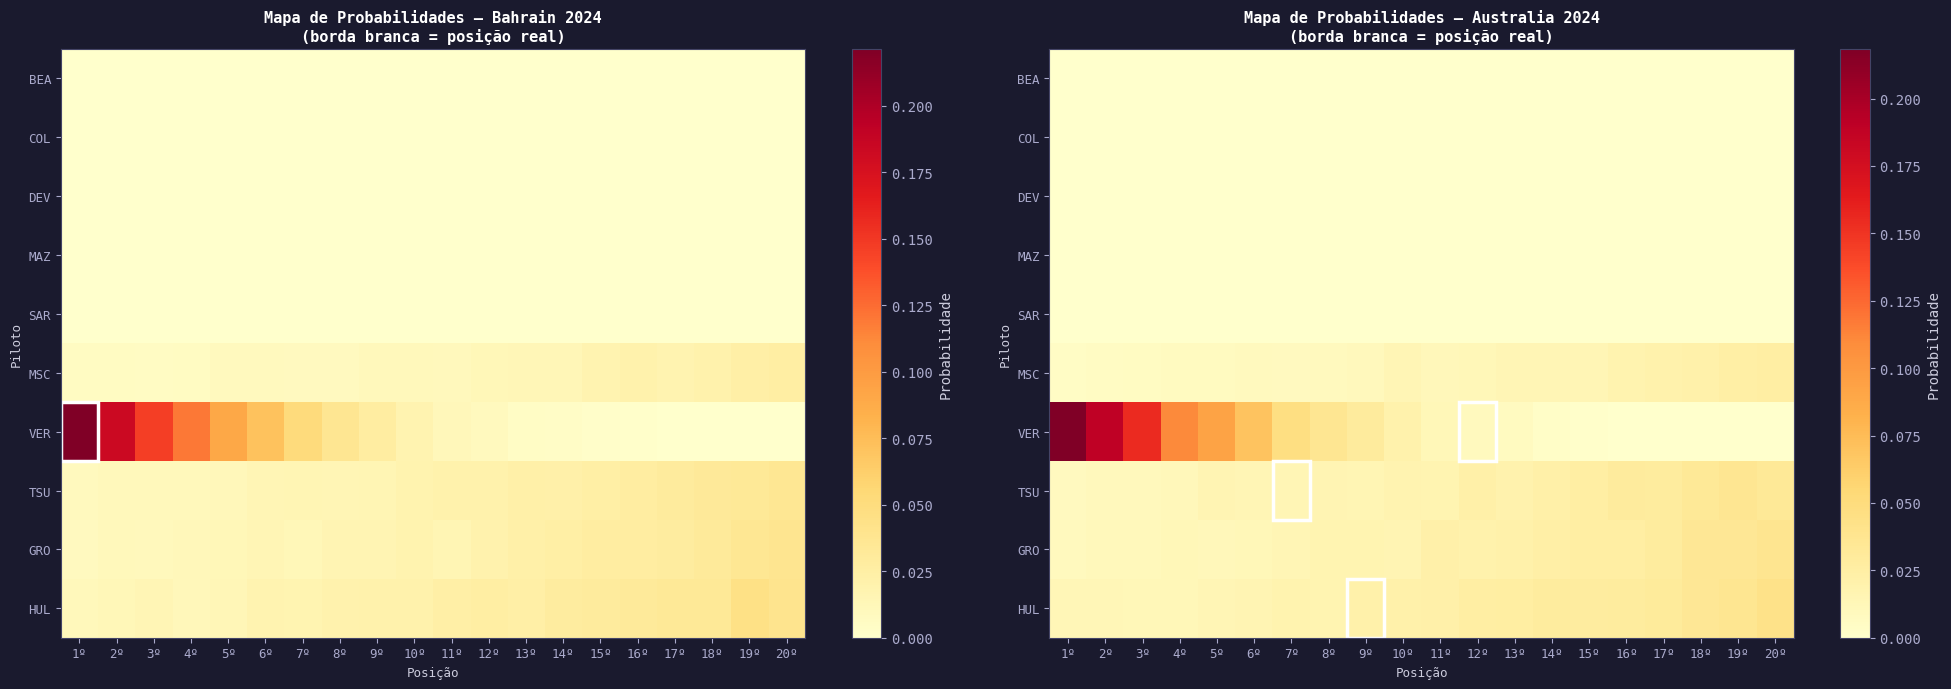

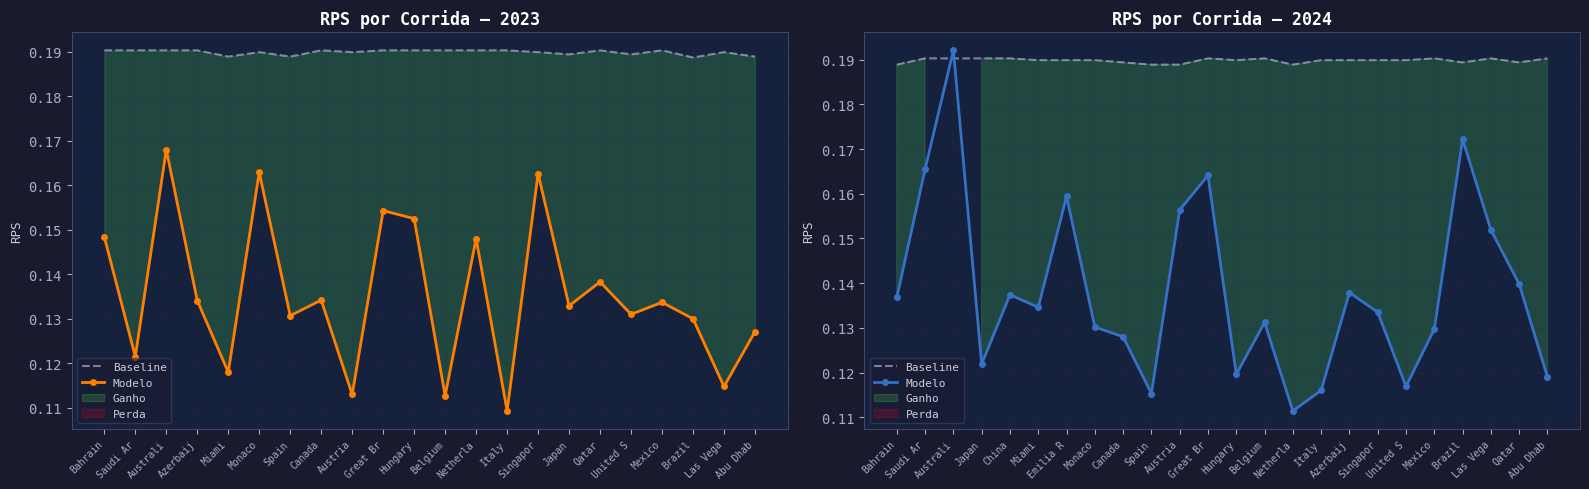

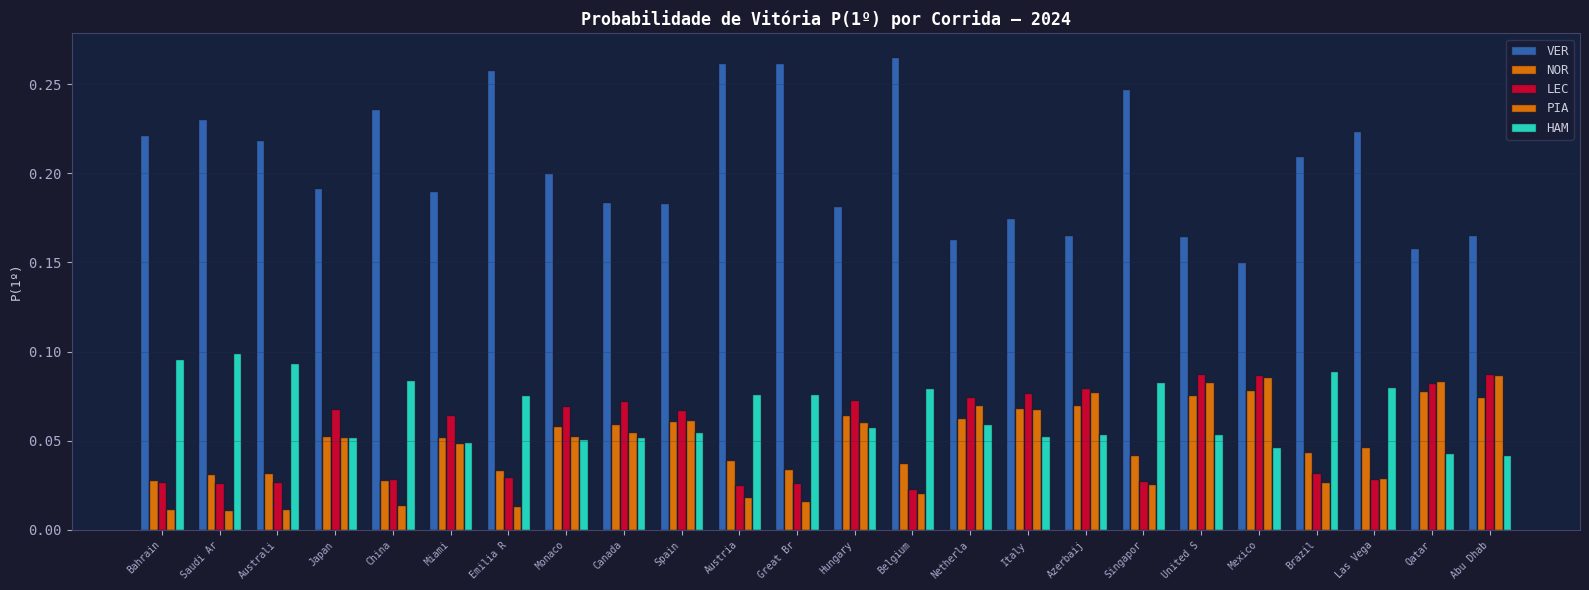

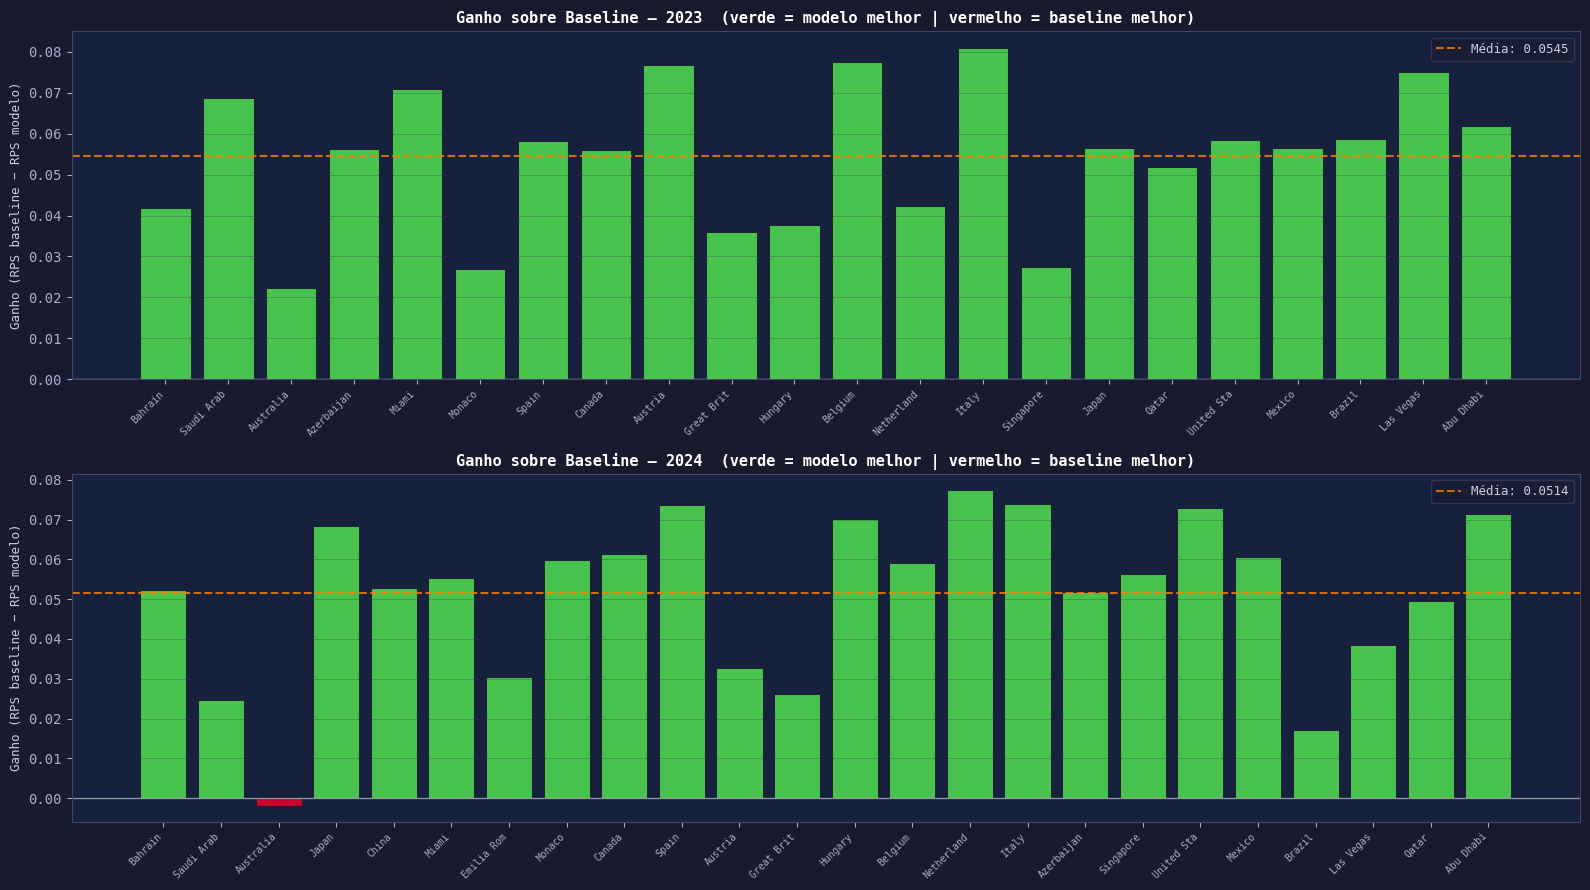

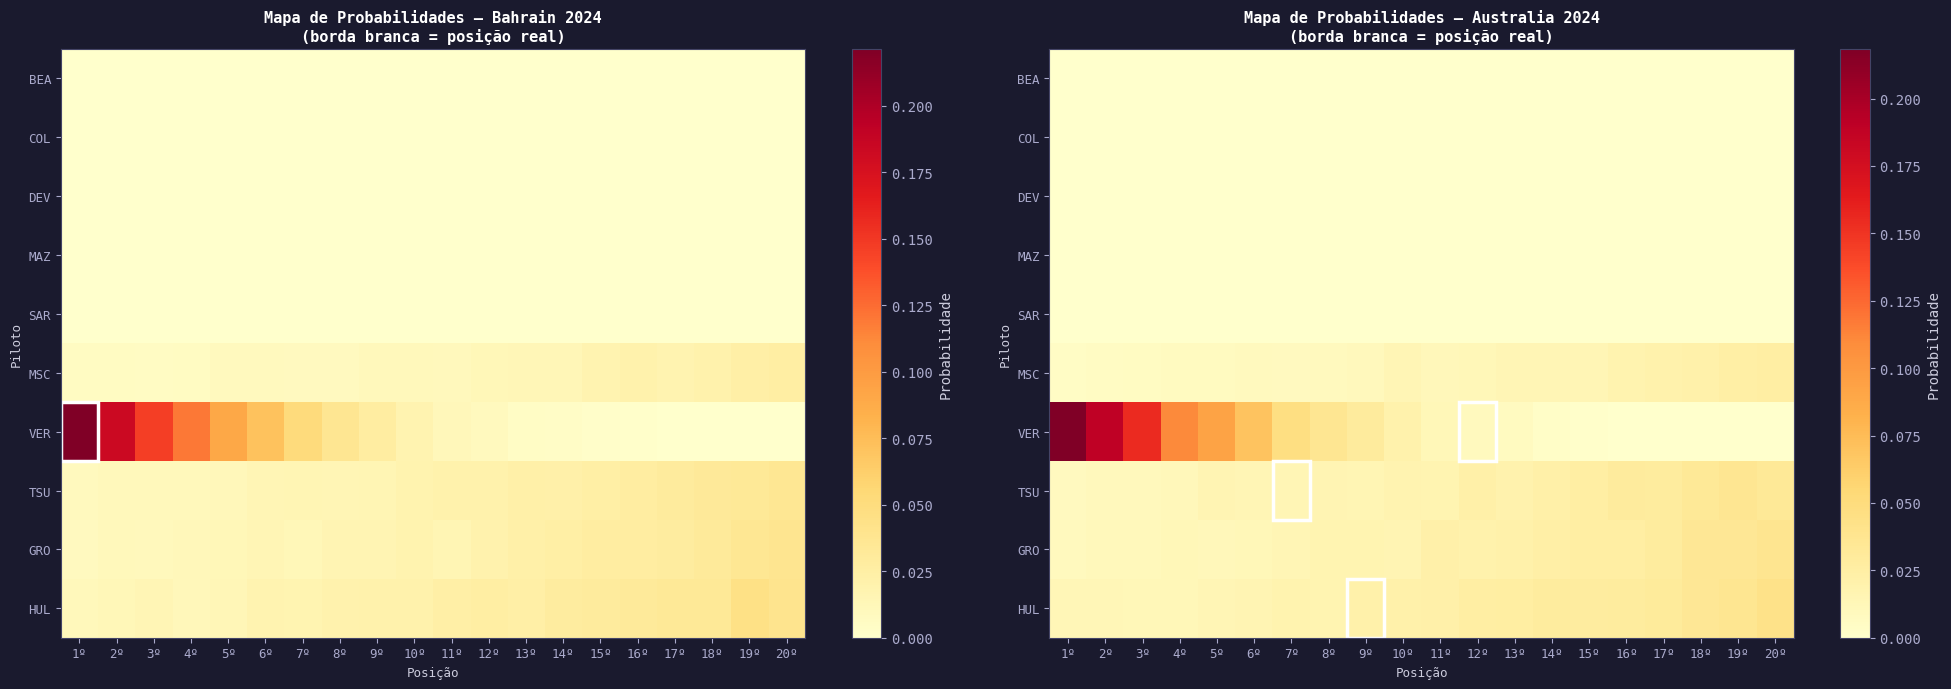

In [16]:
worst_idx = max(range(len(test_rps)), key=lambda i: test_rps[i].rps_model)

fig = plot_probability_heatmap(
    distributions = test_distributions,
    records       = test_records,
    race_indices  = [0, worst_idx],
)
plt.show()


### Viz 2 — Evolução do RPS ao longo das corridas

Linha azul = RPS do modelo. Linha tracejada = baseline.
Área verde = modelo melhor que o baseline.
Área vermelha = baseline melhor que o modelo.


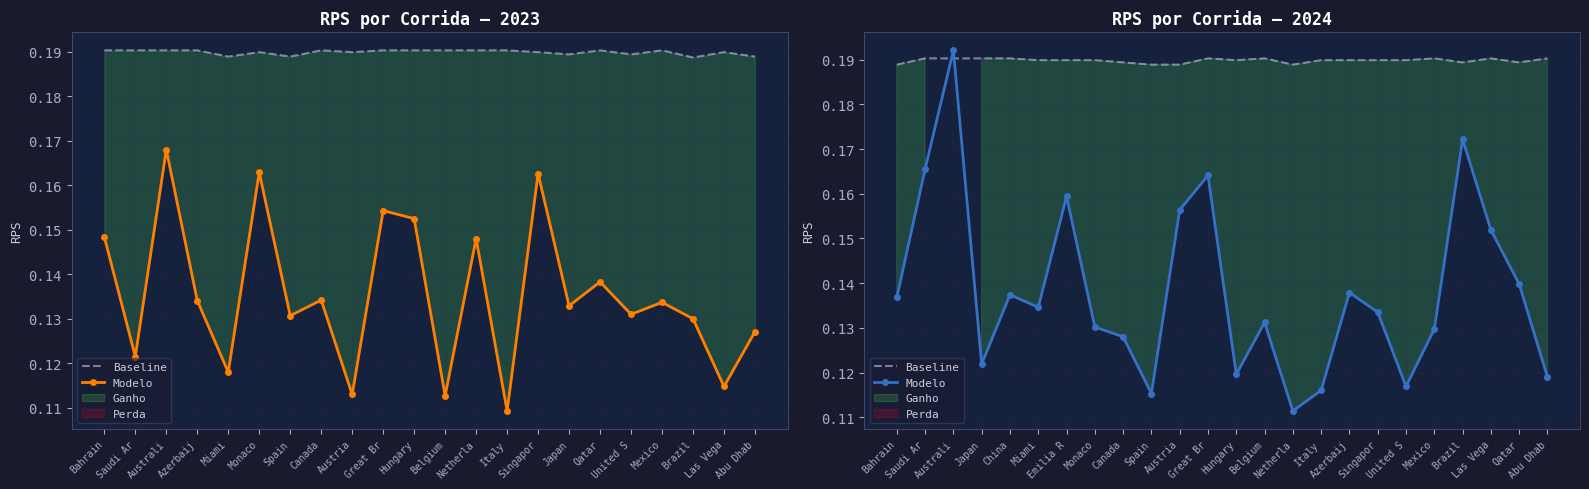

In [17]:
fig = plot_rps_evolution(val_rps=val_rps, test_rps=test_rps)
plt.show()


### Viz 3 — Probabilidades de Vitória P(1º) por Corrida

Para cada corrida do teste (2024), mostra a probabilidade de vitória
dos 5 principais candidatos ao título. Visualiza como o modelo
redistribui as chances ao longo da temporada.


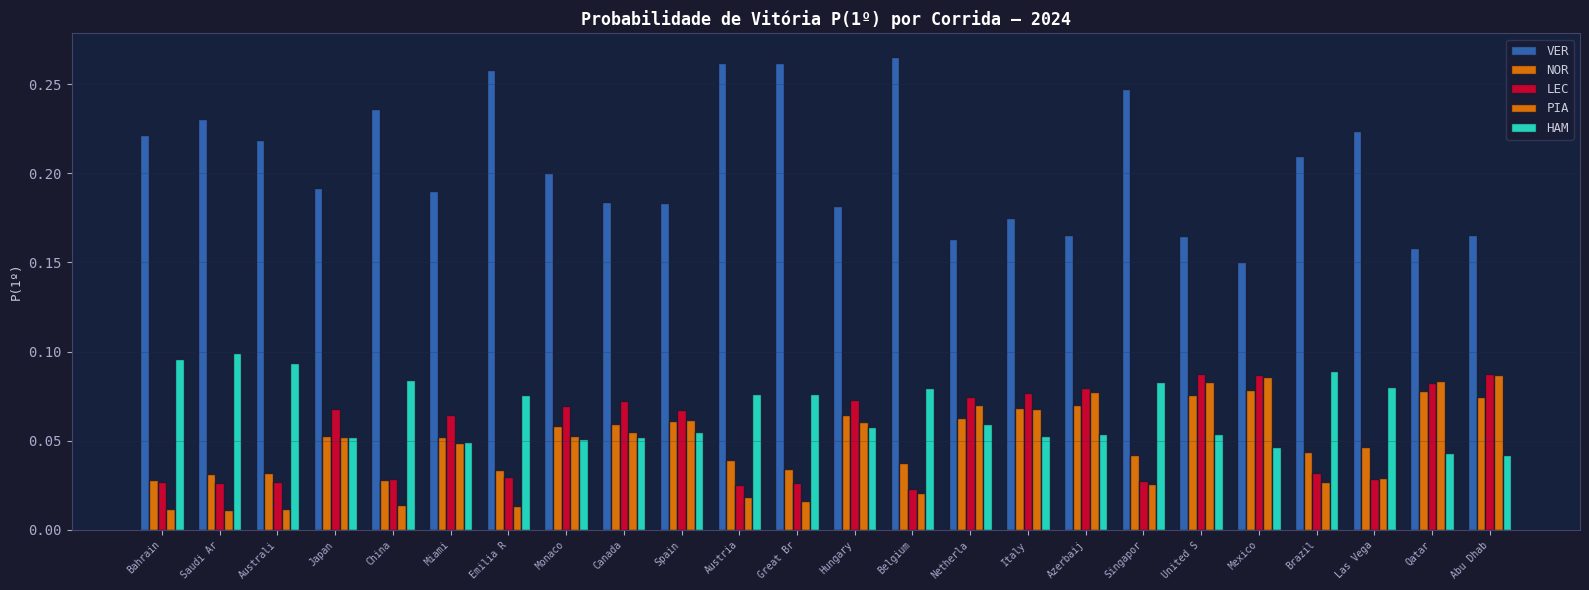

In [18]:
fig = plot_win_probabilities(
    distributions = test_distributions,
    records       = test_records,
    top_drivers   = ['VER', 'NOR', 'LEC', 'PIA', 'HAM'],
    season        = 2024,
)
plt.show()


### Viz 4 — Ganho sobre o Baseline por Corrida

Barras verdes = modelo foi melhor que o baseline.
Barras vermelhas = baseline foi melhor (corridas problemáticas).
Linha tracejada laranja = ganho médio da temporada.


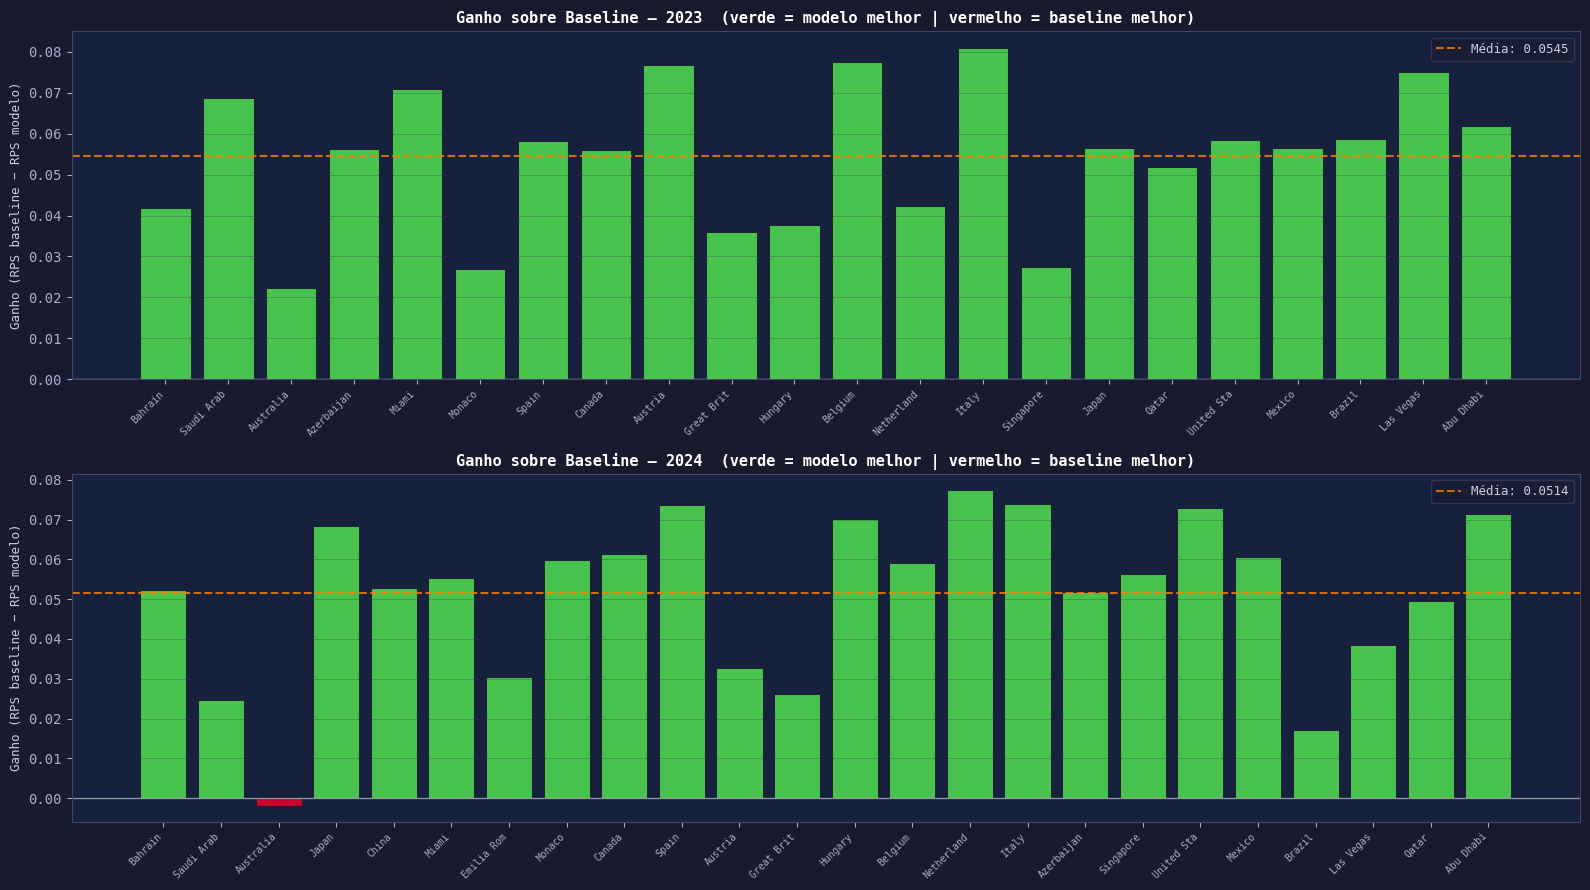

In [19]:
fig = plot_rps_gain(val_rps=val_rps, test_rps=test_rps)
plt.show()


## 5. Análise de Casos Específicos

In [20]:
all_rps = val_rps + test_rps
best    = min(all_rps, key=lambda r: r.rps_model)
worst   = max(all_rps, key=lambda r: r.rps_model)

print(f"Melhor RPS — modelo mais preciso:")
print(f"  Corrida:      {best.race} {best.season}")
print(f"  RPS Modelo:   {best.rps_model:.4f}")
print(f"  RPS Baseline: {best.rps_baseline:.4f}")
print(f"  Ganho:        {best.gain:.4f}")

print(f"\nPior RPS — modelo menos preciso:")
print(f"  Corrida:      {worst.race} {worst.season}")
print(f"  RPS Modelo:   {worst.rps_model:.4f}")
print(f"  RPS Baseline: {worst.rps_baseline:.4f}")
print(f"  Ganho:        {worst.gain:.4f}")
print(f"  Nota: corridas com abandono de favoritos geram RPS alto —")
print(f"        o modelo não consegue prever DNFs.")

all_rps_list = val_rps + test_rps
n_positivo = sum(1 for r in all_rps_list if r.gain > 0)
print(f"\nCorridas com ganho positivo: {n_positivo}/{len(all_rps_list)} "
      f"({n_positivo/len(all_rps_list)*100:.1f}%)")


Melhor RPS — modelo mais preciso:
  Corrida:      Italy 2023
  RPS Modelo:   0.1093
  RPS Baseline: 0.1903
  Ganho:        0.0810

Pior RPS — modelo menos preciso:
  Corrida:      Australia 2024
  RPS Modelo:   0.1921
  RPS Baseline: 0.1903
  Ganho:        -0.0019
  Nota: corridas com abandono de favoritos geram RPS alto —
        o modelo não consegue prever DNFs.

Corridas com ganho positivo: 45/46 (97.8%)


## 6. Conclusões

### Resultados principais

1. **O modelo bate o baseline em ~98% das corridas** — apenas corridas com
   abandono de favoritos têm ganho negativo.

2. **Melhoria de ~32% sobre o baseline na validação e ~30% no teste** —
   as probabilidades geradas têm valor informativo real.

3. **O mapa de calor revela calibração coerente** — pilotos favoritos
   concentram probabilidade nas primeiras posições.

4. **A queda de 32% para 30% entre validação e teste é mínima** —
   o pipeline generaliza bem, sem overfitting.

### Por que o RPS complementa o Top-3 e Kendall τ

O Top-3 e Kendall τ avaliam se o modelo **acertou**.
O RPS avalia se o modelo **sabia o quanto tinha certeza**.

Um modelo que diz "90% para VER" e ele vence tem RPS muito bom.
Um modelo que diz "90% para VER" e outro ganha tem RPS muito ruim —
mesmo que em termos de Top-3 o erro seja "apenas" 1/3.
Isso é informação valiosa sobre a **calibração** do modelo.
